In [1]:
"""
============================================================
INFOTACT INTERNSHIP – PROJECT 2
Supply Chain Analytics: Demand Forecasting & Anomaly Detection
------------------------------------------------------------
WEEK 1: Time-Series Preprocessing & Decomposition
============================================================
Datasets Used:
  1. sales_data.csv            → primary (76,000 rows, 5 categories, daily)
  2. retail_store_inventory.csv → secondary (73,100 rows, Demand Forecast col)
  3. demand_forecasting_dataset.csv → supporting (4,999 rows, future_demand)
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
# 1. Load all 3 files
files = [
    "Customers_A_ID12346-14312.xlsx",
    "Customers_B_ID14314-16283.xlsx",
    "Customers_C_ID16284-18287.xlsx",
]
dfs = [pd.read_excel(f) for f in files]


In [4]:
# 2. Combine into one DataFrame
df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)
df.head(50)

Combined shape: (406829, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,550644,22722,SET OF 6 SPICE TINS PANTRY DESIGN,7,2011-04-19 16:19:00,3.95,12733,USA
1,550644,22979,PANTRY WASHING UP BRUSH,2,2011-04-19 16:19:00,1.45,12733,USA
2,550644,84987,SET OF 36 TEATIME PAPER DOILIES,3,2011-04-19 16:19:00,1.45,12733,USA
3,550644,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1,2011-04-19 16:19:00,4.95,12733,USA
4,550644,22993,SET OF 4 PANTRY JELLY MOULDS,1,2011-04-19 16:19:00,1.25,12733,USA
5,550644,47580,TEA TIME DES TEA COSY,3,2011-04-19 16:19:00,2.55,12733,USA
6,550644,22989,SET 2 PANTRY DESIGN TEA TOWELS,6,2011-04-19 16:19:00,3.25,12733,USA
7,550644,22900,SET 2 TEA TOWELS I LOVE LONDON,3,2011-04-19 16:19:00,3.25,12733,USA
8,550644,22128,PARTY CONES CANDY ASSORTED,12,2011-04-19 16:19:00,1.25,12733,USA
9,550644,47590B,PINK HAPPY BIRTHDAY BUNTING,4,2011-04-19 16:19:00,5.45,12733,USA


In [5]:
# 3. Basic info
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe())



Missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Summary statistics:
             Quantity                    InvoiceDate      UnitPrice  \
count  406829.000000                         406829  406829.000000   
mean       12.061303  2011-07-13 05:50:35.511038208       3.460471   
min    -80995.000000            2010-12-01 08:26:00       0.000000   
25%         2.000000            2011-04-07 18:09:00       1.250000   
50%         5.000000            2011-08-01 11:23:00       1.950000   
75%        12.000000            2011-10-21 08:40:00       3.750000   
max     80995.000000            2014-11-12 08:26:00   38970.000000   
std       248.693370                            NaN      69.315162   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.00000

In [6]:
# 4. Add Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [7]:
# 5. Basic aggregations
top_countries = df["Country"].value_counts().head(10)
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

print("\nTop 10 countries by order count:\n", top_countries)
print("\nTop 10 countries by revenue:\n", revenue_by_country)


Top 10 countries by order count:
 Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1480
Australia           1259
Name: count, dtype: int64

Top 10 countries by revenue:
 Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64


In [8]:
# 1. Build a daily time series from the cleaned data
# Group all transactions by date and sum the Revenue for each day
daily_sales = df.groupby(df["InvoiceDate"].dt.date)["Revenue"].sum()

# Convert the index to a proper datetime type
daily_sales.index = pd.to_datetime(daily_sales.index)

daily_sales = daily_sales.sort_index()
daily_sales.head()

InvoiceDate
2010-12-01    13717.33
2010-12-02    45795.77
2010-12-03    22620.46
2010-12-04       20.34
2010-12-05    31400.94
Name: Revenue, dtype: float64

In [17]:
# 4. Look at each component separately
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Trend (first 10 non-null values):")
print(trend.dropna().head(10))

print("\nSeasonal component (first 10 values):")
print(seasonal.head(10))

print("\nResidual (first 10 non-null values):")
print(residual.dropna().head(10))

Trend (first 10 non-null values):
InvoiceDate
2010-12-04    28169.530000
2010-12-05    31647.022857
2010-12-06    30417.477143
2010-12-07    31765.901429
2010-12-08    31764.795714
2010-12-09    29740.407143
2010-12-10    29308.842857
2010-12-11    25561.960000
2010-12-12    24315.747143
2010-12-13    25863.951429
Name: trend, dtype: float64

Seasonal component (first 10 values):
InvoiceDate
2010-12-01    1540.387725
2010-12-02    3399.380178
2010-12-03     285.456427
2010-12-04   -5729.324148
2010-12-05   -1921.715204
2010-12-06     499.440455
2010-12-07    1926.374566
2010-12-08    1540.387725
2010-12-09    3399.380178
2010-12-10     285.456427
Name: seasonal, dtype: float64

Residual (first 10 non-null values):
InvoiceDate
2010-12-04   -22419.865852
2010-12-05     1675.632347
2010-12-06     -436.537598
2010-12-07    19459.214005
2010-12-08     4754.596561
2010-12-09     4049.162679
2010-12-10     2465.130716
2010-12-11   -19820.035852
2010-12-12    -5163.811939
2010-12-13     1096.0

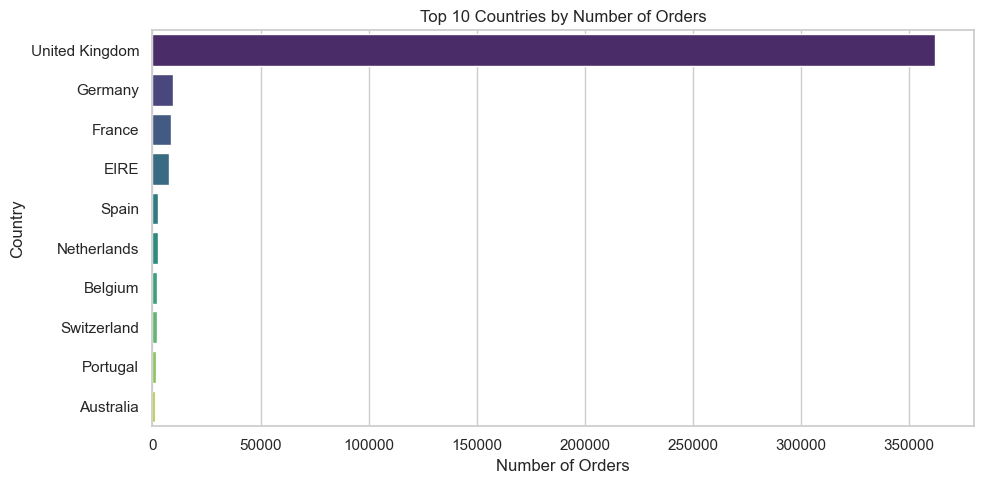

In [26]:
# ------------------------------------------------------------------
# Seaborn visualizations
# ------------------------------------------------------------------

# Plot 1: Top 10 countries by number of orders (bar chart)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette="viridis", legend=False)
plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries_orders.png", dpi=150)
plt.show()

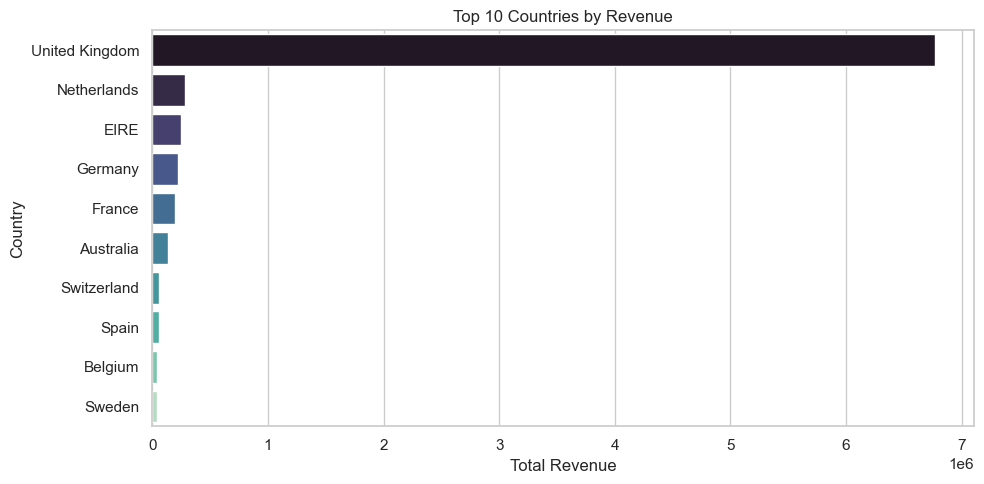

In [10]:
# Plot 2: Top 10 countries by revenue (bar chart)
plt.figure(figsize=(10, 5))
sns.barplot(x=revenue_by_country.values, y=revenue_by_country.index, hue=revenue_by_country.index,
            palette="mako", legend=False)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top_countries_revenue.png", dpi=150)
plt.show()

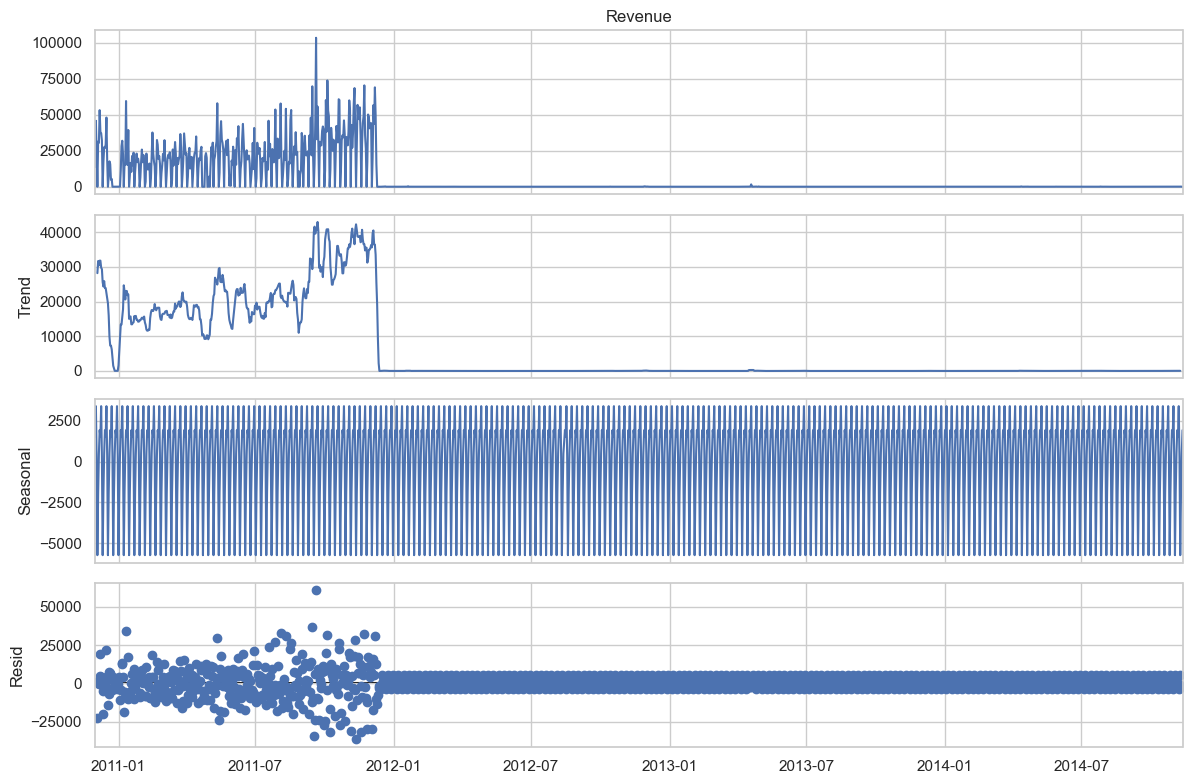

In [16]:
# PLOT 3. Decompose the time series using statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

# period=7 because we expect a weekly seasonal pattern in daily retail data
decomposition = seasonal_decompose(daily_sales, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("seasonal_decomposition.png", dpi=150)
plt.show()

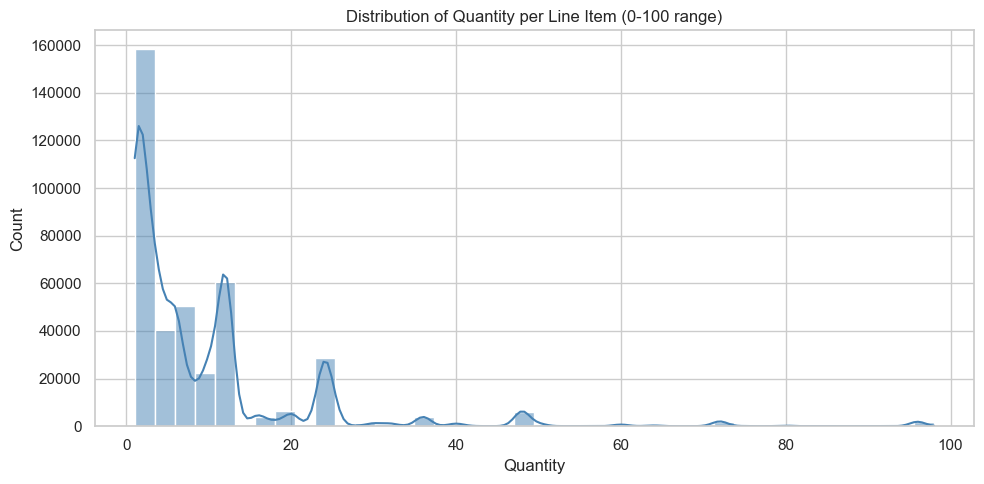

In [11]:
# Plot 4: Distribution of Quantity (histogram), clipped to remove extreme outliers for readability
plt.figure(figsize=(10, 5))
sns.histplot(df[(df["Quantity"] > 0) & (df["Quantity"] < 100)]["Quantity"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Quantity per Line Item (0-100 range)")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("quantity_distribution.png", dpi=150)
plt.show()

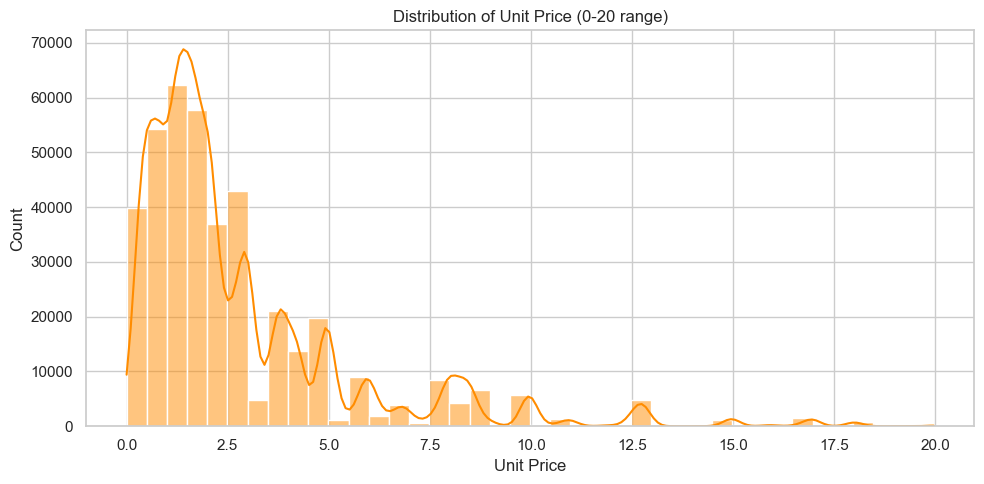

In [12]:
# Plot 5: Distribution of UnitPrice (histogram), clipped for readability
plt.figure(figsize=(10, 5))
sns.histplot(df[(df["UnitPrice"] > 0) & (df["UnitPrice"] < 20)]["UnitPrice"], bins=40, kde=True, color="darkorange")
plt.title("Distribution of Unit Price (0-20 range)")
plt.xlabel("Unit Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("unitprice_distribution.png", dpi=150)
plt.show()


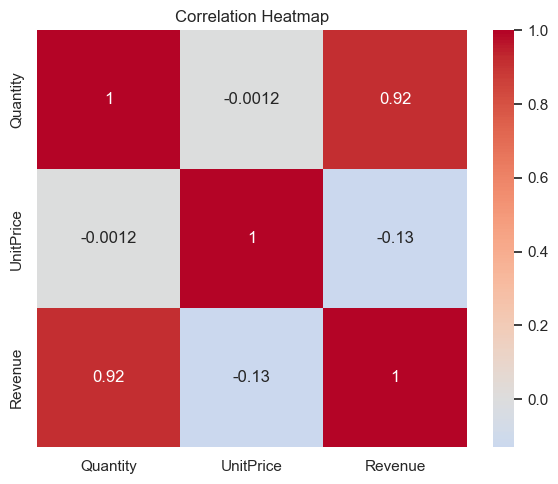

In [13]:
# Plot 6: Correlation heatmap of numeric columns
plt.figure(figsize=(6, 5))
numeric_cols = df[["Quantity", "UnitPrice", "Revenue"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

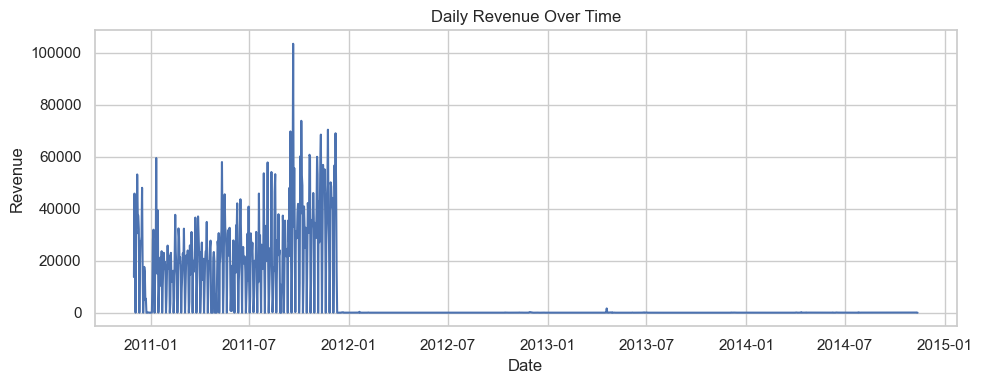

In [25]:
# Quick look at the cleaned daily time series
plt.figure(figsize=(10, 4))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("daily_revenue_timeseries.png", dpi=150)
plt.show()

In [14]:

print("\nAll plots saved: top_countries_orders.png, top_countries_revenue.png, "
      "quantity_distribution.png, unitprice_distribution.png, correlation_heatmap.png")


All plots saved: top_countries_orders.png, top_countries_revenue.png, quantity_distribution.png, unitprice_distribution.png, correlation_heatmap.png
